# Xente Transaction Data EDA

Executed exploratory data analysis for the Credit Risk Probability Model for Alternative Data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = '../data/raw/Data/data.csv'
df = pd.read_csv(DATA_PATH)
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'], utc=True)
print('Shape:', df.shape)
df.head()

Shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15 03:34:21+00:00,2,0


## Dataset Overview

In [2]:
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'unique_values': df.nunique()
})
overview

,dtype,missing,missing_pct,unique_values
TransactionId,str,0,0.0,95662
BatchId,str,0,0.0,94809
AccountId,str,0,0.0,3633
SubscriptionId,str,0,0.0,3627
CustomerId,str,0,0.0,3742
CurrencyCode,str,0,0.0,1
CountryCode,int64,0,0.0,1
ProviderId,str,0,0.0,6
ProductId,str,0,0.0,23
ProductCategory,str,0,0.0,9


## Summary Statistics

In [3]:
df.describe(include='all').transpose()

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
TransactionId,95662,95662,TransactionId_76871,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BatchId,95662,94809,BatchId_67019,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AccountId,95662,3633,AccountId_4841,30893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SubscriptionId,95662,3627,SubscriptionId_3829,32630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerId,95662,3742,CustomerId_7343,4091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CurrencyCode,95662,1,UGX,95662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CountryCode,95662.0,NaN,NaN,NaN,256.0,256.0,256.0,256.0,256.0,256.0,0.0
ProviderId,95662,6,ProviderId_4,38189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductId,95662,23,ProductId_6,32635,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProductCategory,95662,9,financial_services,45405,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Numerical Distributions

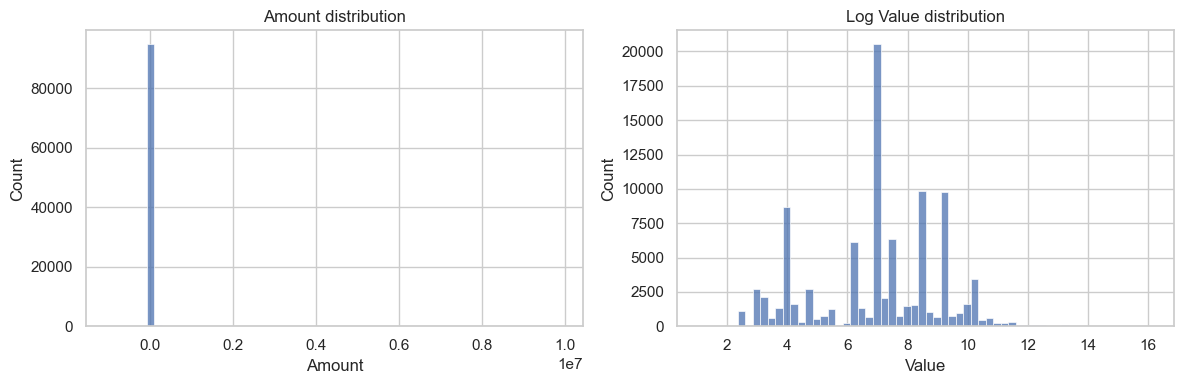

In [4]:
numeric_cols = ['Amount', 'Value', 'CountryCode', 'PricingStrategy', 'FraudResult']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Amount'], bins=60, ax=axes[0])
axes[0].set_title('Amount distribution')
sns.histplot(np.log1p(df['Value']), bins=60, ax=axes[1])
axes[1].set_title('Log Value distribution')
plt.tight_layout()

## Categorical Distributions

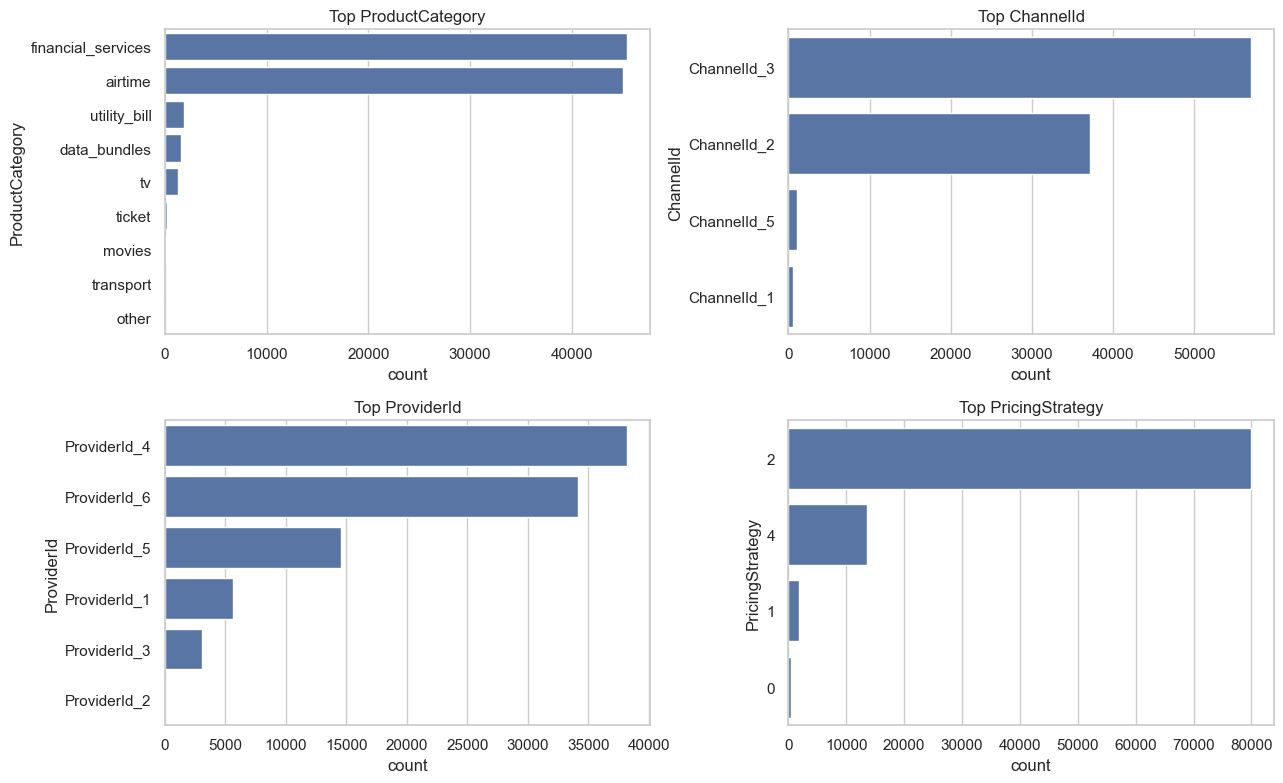

In [5]:
categorical_cols = ['ProductCategory', 'ChannelId', 'ProviderId', 'PricingStrategy']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), categorical_cols):
    order = df[col].astype(str).value_counts().head(10).index
    sns.countplot(data=df, y=df[col].astype(str), order=order, ax=ax)
    ax.set_title(f'Top {col}')
plt.tight_layout()

## Correlation Analysis

,Amount,Value,CountryCode,PricingStrategy,FraudResult
Amount,1.000000,0.989692,NaN,-0.061931,0.557370
Value,0.989692,1.000000,NaN,-0.017020,0.566739
CountryCode,NaN,NaN,NaN,NaN,NaN
PricingStrategy,-0.061931,-0.017020,NaN,1.000000,-0.033821
FraudResult,0.557370,0.566739,NaN,-0.033821,1.000000


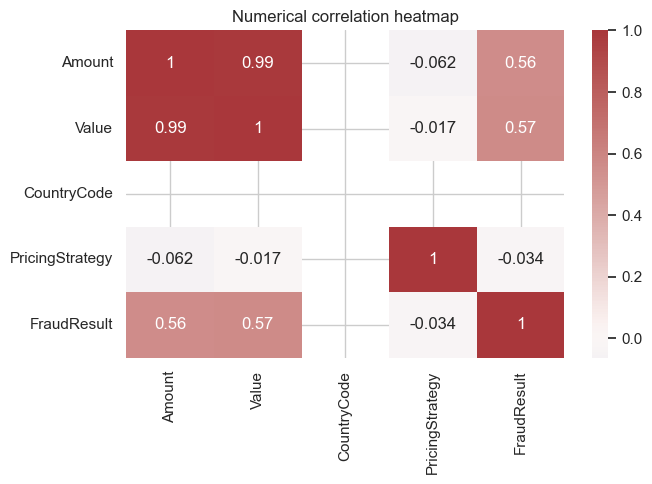

In [6]:
corr = df[numeric_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Numerical correlation heatmap')
plt.tight_layout()
corr

## Missing Value Assessment

In [7]:
missing = df.isna().sum().sort_values(ascending=False).to_frame('missing_count')
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
TransactionId,0,0.0
BatchId,0,0.0
AccountId,0,0.0
SubscriptionId,0,0.0
CustomerId,0,0.0
CurrencyCode,0,0.0
CountryCode,0,0.0
ProviderId,0,0.0
ProductId,0,0.0
ProductCategory,0,0.0


## Outlier Detection

,column,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,Amount,-50.0,2800.0,2850.0,-4325.0,7075.0,24441,25.55
1,Value,275.0,5000.0,4725.0,-6812.5,12087.5,9021,9.43


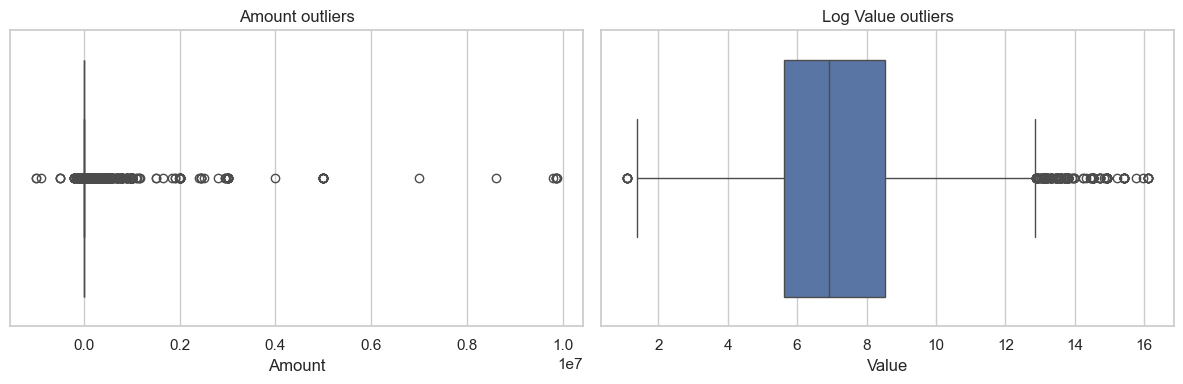

In [8]:
outlier_summary = []
for col in ['Amount', 'Value']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'column': col, 'q1': q1, 'q3': q3, 'iqr': iqr,
        'lower_fence': lower, 'upper_fence': upper,
        'outlier_count': int(outliers), 'outlier_pct': round(outliers / len(df) * 100, 2)
    })
outlier_summary = pd.DataFrame(outlier_summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df['Amount'], ax=axes[0])
axes[0].set_title('Amount outliers')
sns.boxplot(x=np.log1p(df['Value']), ax=axes[1])
axes[1].set_title('Log Value outliers')
plt.tight_layout()
outlier_summary

## Customer-Level Risk-Relevant View

In [9]:
customer = df.groupby('CustomerId').agg(
    transaction_count=('TransactionId', 'count'),
    total_amount=('Amount', 'sum'),
    average_amount=('Amount', 'mean'),
    std_amount=('Amount', 'std'),
    total_value=('Value', 'sum'),
    fraud_count=('FraudResult', 'sum'),
    first_transaction=('TransactionStartTime', 'min'),
    last_transaction=('TransactionStartTime', 'max')
).reset_index()
customer['std_amount'] = customer['std_amount'].fillna(0)
customer['recency_days'] = (df['TransactionStartTime'].max() + pd.Timedelta(days=1) - customer['last_transaction']).dt.days
print('Customers:', customer.shape[0])
customer.describe().transpose()

Customers: 3742


,count,mean,std,min,25%,50%,75%,max
transaction_count,3742.0,25.564404,9.692960e+01,1.0,2.000000,7.000000,20.000000,4.091000e+03
total_amount,3742.0,171737.740647,2.717305e+06,-104900000.0,4077.437500,20000.000000,79967.750000,8.345124e+07
average_amount,3742.0,15715.616012,1.676991e+05,-425000.0,1000.000000,2583.846429,4877.613636,8.601821e+06
std_amount,3742.0,13605.166177,9.689344e+04,0.0,501.141058,3184.898145,6745.368782,3.309916e+06
total_value,3742.0,253102.528327,2.715877e+06,50.0,6500.000000,32000.000000,102060.000000,1.049000e+08
fraud_count,3742.0,0.051577,7.743284e-01,0.0,0.000000,0.000000,0.000000,3.100000e+01
recency_days,3742.0,31.461251,2.711893e+01,1.0,6.000000,25.000000,54.000000,9.100000e+01


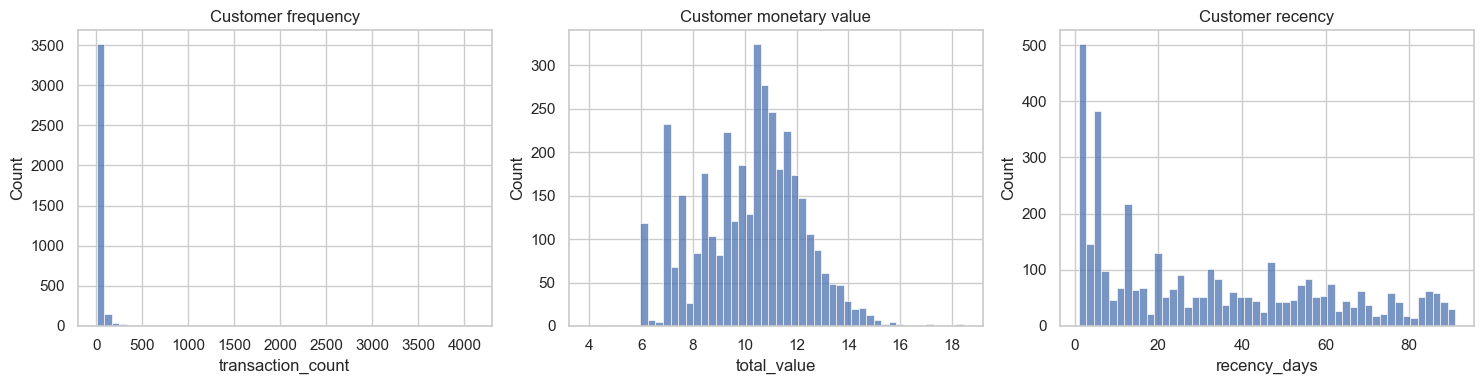

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(customer['transaction_count'], bins=50, ax=axes[0])
axes[0].set_title('Customer frequency')
sns.histplot(np.log1p(customer['total_value']), bins=50, ax=axes[1])
axes[1].set_title('Customer monetary value')
sns.histplot(customer['recency_days'], bins=50, ax=axes[2])
axes[2].set_title('Customer recency')
plt.tight_layout()

## Key Insights Summary

1. The dataset contains 95,662 transactions for 3,742 customers, so customer-level aggregation is required before building a credit scoring model.
2. There are no missing values in the raw fields, but modeling code should still include imputation for future scoring robustness.
3. Transaction `Amount` and `Value` are highly skewed with material outliers, so scaling and/or robust transformations are important before clustering or linear modeling.
4. Product and channel usage is concentrated in a small number of categories, making one-hot encoding practical for the main categorical variables.
5. The raw data has a fraud flag but no true loan-default label, so the project must use a clearly documented proxy target and treat model metrics as proxy-label performance rather than proven default prediction.